In [3]:
!pip install opendatasets opencv-python albumentations lime shap scikit-image

  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b2c9d749e8d16ce49732c81b555e49d2c2d4de69dd8e6032245c4c757e9a93ba
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [54]:
import os
import cv2
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import albumentations as A
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
import opendatasets as od
ham_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
isic_url = "https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic"

print("Downloading HAM10000...")
od.download(ham_url)
print("Downloading ISIC 9 Classes...")
od.download(isic_url)

master_dir = 'unified_dataset'
os.makedirs(master_dir, exist_ok=True)

ham_mapping = {'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
               'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
               'vasc': 'vascular_lesion'}

isic_mapping = {'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
                'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
                'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
                'squamous cell carcinoma': 'actinic_keratosis', 'vascular lesion': 'vascular_lesion'}

ham_base = 'skin-cancer-mnist-ham10000'
metadata = pd.read_csv(f'{ham_base}/HAM10000_metadata.csv')
ham_folders = [f'{ham_base}/ham10000_images_part_1', f'{ham_base}/ham10000_images_part_2']

print("Processing HAM10000...")
for _, row in metadata.iterrows():
    label = ham_mapping[row['dx']]
    dest = os.path.join(master_dir, label)
    os.makedirs(dest, exist_ok=True)
    img_name = row['image_id'] + '.jpg'
    for folder in ham_folders:
        src = os.path.join(folder, img_name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest, img_name))
            break

print("Processing ISIC 9 Classes...")
isic_root = 'skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
for split in ['Train', 'Test']:
    split_path = os.path.join(isic_root, split)
    if not os.path.exists(split_path): continue
    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            dest_folder = os.path.join(master_dir, target_label)
            os.makedirs(dest_folder, exist_ok=True)
            src_folder = os.path.join(split_path, folder_name)
            for img in os.listdir(src_folder):
                safe_img_name = f"isic9_{split.lower()}_{img}"
                shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, safe_img_name))

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnasser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:40<00:00, 139MB/s] 



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnaser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic


100%|██████████| 786M/786M [00:11<00:00, 71.7MB/s]



Processing HAM10000...
Processing ISIC 9 Classes...


In [7]:
balanced_dir = 'balanced_dataset'
TARGET_COUNT = 2000

if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir)

transform = A.Compose([
    A.Resize(192, 192),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=25,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.CLAHE(p=0.3),
])

print("Balancing classes to 2000 images each...")
for class_name in os.listdir(master_dir):
    src_dir = os.path.join(master_dir, class_name)
    dst_dir = os.path.join(balanced_dir, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    images = [img for img in os.listdir(src_dir) if img.endswith(('.jpg','.png','.jpeg'))]

    if len(images) >= TARGET_COUNT:
        selected = random.sample(images, TARGET_COUNT)
        for img in selected:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))
    else:
        for img in images:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))

        while len(os.listdir(dst_dir)) < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(src_dir, img_name)

            img = cv2.imread(img_path)
            if img is None: continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            aug = transform(image=img)['image']
            aug = cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)

            new_name = f"aug_{random.randint(0,999999)}.jpg"
            cv2.imwrite(os.path.join(dst_dir, new_name), aug)

Balancing classes to 2000 images each...


In [8]:
def remove_hair(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))

    blackhat = cv2.morphologyEx(
        gray,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    _, thresh = cv2.threshold(
        blackhat,
        10,
        255,
        cv2.THRESH_BINARY
    )

    result = cv2.inpaint(
        img,
        thresh,
        1,
        cv2.INPAINT_TELEA
    )

    return result

In [9]:
clean_dir = 'clean_dataset'
os.makedirs(clean_dir, exist_ok=True)

for file in os.listdir(master_dir):

    path = os.path.join(master_dir, file)

    img = cv2.imread(path)

    if img is None:
        continue

    img = remove_hair(img)

In [13]:
clean_dir = 'clean_dataset'
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)
os.makedirs(clean_dir, exist_ok=True)

total_images_processed = 0

for class_name in os.listdir(master_dir):
    src_class_dir = os.path.join(master_dir, class_name)
    dst_class_dir = os.path.join(clean_dir, class_name)
    os.makedirs(dst_class_dir, exist_ok=True)

    if os.path.isdir(src_class_dir):
        for file_name in os.listdir(src_class_dir):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(src_class_dir, file_name)
                img = cv2.imread(path)

                if img is None:
                    print(f"Warning: Could not read image {path}. Skipping.")
                    continue

                img = remove_hair(img)


                h, w = img.shape[:2]
                crop_ratio = 0.8
                new_h = int(h * crop_ratio)
                new_w = int(w * crop_ratio)
                start_x = (w - new_w) // 2
                start_y = (h - new_h) // 2
                img = img[
                    start_y:start_y+new_h,
                    start_x:start_x+new_w
                ]
                img = cv2.resize(img, (192, 192))

                save_path = os.path.join(dst_class_dir, file_name)
                cv2.imwrite(save_path, img)
                total_images_processed += 1

print(f'Hair removal preprocessing complete. Processed {total_images_processed} images.')

Hair removal preprocessing complete. Processed 12372 images.


In [16]:
all_images = []

for root, dirs, files in os.walk(clean_dir):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            all_images.append(os.path.join(root, file))

print(len(all_images))

12372


In [26]:
clean_dir = 'clean_dataset'

train_dir = 'train'
val_dir = 'val'
test_dir = 'test'

classes = os.listdir(clean_dir)

for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)

    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)


for cls in classes:

    class_path = os.path.join(clean_dir, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.endswith(('.jpg', '.png', '.jpeg'))
    ]

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, cls, img)
        )


    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, cls, img)
        )


In [51]:
BATCH_SIZE = 32
IMG_SIZE = 300

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [52]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='categorical'
)

NUM_CLASSES = train_data.num_classes
class_names = list(train_data.class_indices.keys())

Found 8656 images belonging to 7 classes.
Found 1857 images belonging to 7 classes.
Found 1859 images belonging to 7 classes.


In [55]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation='swish',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation='swish',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(base_model.input, output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [56]:
drive_model_path = 'best_resnet50.keras'

cb = [

   callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True

    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        drive_model_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [57]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

In [60]:
model.compile(
    optimizer=Adam(1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

print('Starting Phase 1 Training...')

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=cb
)


Starting Phase 1 Training...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.6481 - loss: 1.3069
Epoch 1: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.6411 - loss: 1.3173 - val_accuracy: 0.6575 - val_loss: 1.2552 - learning_rate: 1.0000e-04
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.6319 - loss: 1.3155
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 2: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 228s 841ms/step - accuracy: 0.6401 - loss: 1.3153 - val_accuracy: 0.6602 - val_loss: 1.2492 - learning_rate: 1.0000e-04
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.6475 - loss: 1.3065
Epoch 3: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 232s 856ms/step - accuracy: 0.6468 - loss: 1.2976 - val_accuracy: 0.6694 - val_loss: 1.2401 - learning_rate: 3.0000e-05
Epoch 4/20
271/271 ━━━━━━━━━━━━━

In [61]:
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False
model.compile(
    optimizer=Adam(1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)


In [ ]:
print('Starting Phase 2 Fine-Tuning...')

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=cb
)



Starting Phase 2 Fine-Tuning...
Epoch 1/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.6068 - loss: 1.4319
Epoch 1: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.6046 - loss: 1.4203 - val_accuracy: 0.6381 - val_loss: 1.3137 - learning_rate: 1.0000e-05
Epoch 2/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.6016 - loss: 1.4148
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 2: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 235s 866ms/step - accuracy: 0.6115 - loss: 1.3891 - val_accuracy: 0.6392 - val_loss: 1.3215 - learning_rate: 1.0000e-05
Epoch 3/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.6067 - loss: 1.3973
Epoch 3: val_accuracy did not improve from 0.67151
271/271 ━━━━━━━━━━━━━━━━━━━━ 233s 860ms/step - accuracy: 0.6195 - loss: 1.3710 - val_accuracy: 0.6505 - val_loss: 1.2908 - learning_rate: 3.0000e-06
Epoch 4/25
271/271 ━━━━━━━━━━

In [62]:
best_model = tf.keras.models.load_model(drive_model_path)

loss, acc = best_model.evaluate(test_data)

print(f'Test Accuracy: {acc*100:.2f}%')

59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 452ms/step - accuracy: 0.6772 - loss: 1.2421
Test Accuracy: 67.72%


In [47]:
pred_probs = best_model.predict(test_data)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step
                      precision    recall  f1-score   support

   actinic_keratosis       0.51      0.35      0.42        99
basal_cell_carcinoma       0.72      0.63      0.67       136
    benign_keratosis       0.54      0.53      0.53       249
      dermatofibroma       0.79      0.32      0.46        34
    melanocytic_nevi       0.82      0.94      0.88      1062
            melanoma       0.63      0.38      0.48       236
     vascular_lesion       0.79      0.88      0.84        43

            accuracy                           0.75      1859
           macro avg       0.68      0.58      0.61      1859
        weighted avg       0.73      0.75      0.73      1859



In [49]:
auc = roc_auc_score(
    tf.keras.utils.to_categorical(y_true),
    pred_probs,
    multi_class='ovr'
)

print(f'AUC Score: {auc:.4f}')

AUC Score: 0.9285


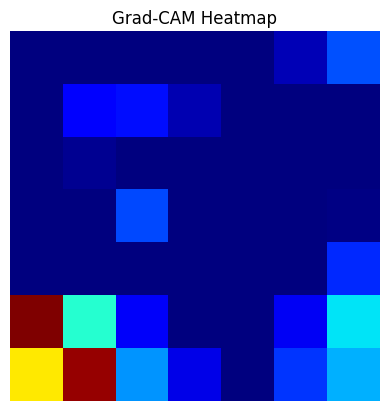

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━

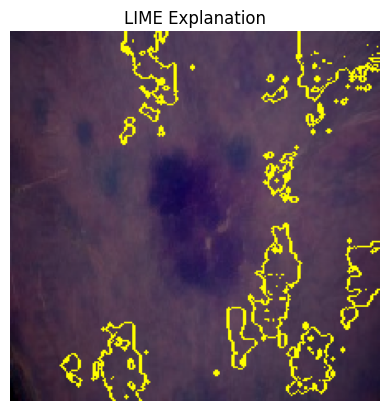

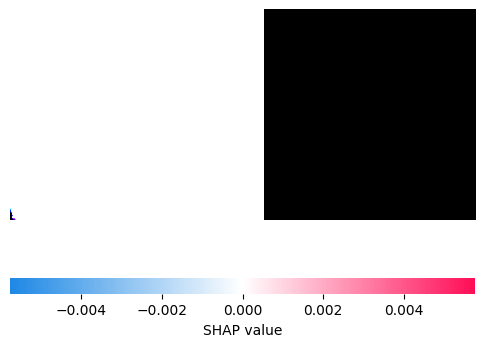

In [50]:
def prep_img_for_xai(img_path):

    img = image.load_img(img_path, target_size=(224, 224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    return img_array

def run_gradcam(
    img_path,
    model,
    last_conv_layer_name='conv5_block3_out'
):

    img_array = prep_img_for_xai(img_path)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    plt.imshow(heatmap, cmap='jet')
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')
    plt.show()

def run_lime(img_path, model):

    img_array = prep_img_for_xai(img_path)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img_array[0].astype('double'),
        model.predict,
        top_labels=3,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title('LIME Explanation')
    plt.axis('off')
    plt.show()

def run_shap(img_path, model, bg_data_gen):

    img_array = prep_img_for_xai(img_path)

    bg_images, _ = next(bg_data_gen)

    explainer = shap.GradientExplainer(model, bg_images)

    shap_values, indexes = explainer.shap_values(
        img_array,
        ranked_outputs=1
    )

    shap.image_plot(shap_values, img_array)
sample_class = class_names[0]

sample_img_name = os.listdir(
    os.path.join(test_dir, sample_class)
)[0]

sample_img_path = os.path.join(
    test_dir,
    sample_class,
    sample_img_name
)

run_gradcam(sample_img_path, best_model)
run_lime(sample_img_path, best_model)
run_shap(sample_img_path, best_model, val_data)